# Task 3: Real-Time Echocardiogram Video Analysis

**Goal:** Build a real-time OpenCV pipeline that reads an ultrasound
(.mp4) video frame by frame, applies mathematical enhancements to combat
murky/low-contrast/noisy footage, and displays the corrected feed live
alongside the raw feed.

Pipeline per frame: Histogram Equalization -> Color Mapping (JET) ->
Color Balance -> Log Transform -> Power-Law (Gamma) Transform ->
side-by-side monitoring array.

> **Note on `cv2.imshow` in notebooks/headless environments:** `cv2.imshow()`
> opens a native OS window and requires a display + a running local Python
> process (not a headless server/CI/cloud notebook). The code below is
> written exactly as it should run **locally** (uncomment the `imshow` /
> `waitKey` lines). For this notebook environment (no display attached) we
> additionally save the monitoring array frames to `output/` and compile a
> preview video, so the pipeline can still be verified end-to-end without a
> GUI.


In [1]:
import cv2
import numpy as np
import os

os.makedirs('output', exist_ok=True)
SHOW_WINDOW = False  # set True when running locally with a display attached


## 1. Video Capture Setup
Initialize `cv2.VideoCapture()` to read from the provided ultrasound `.mp4`
file (not a webcam).

In [2]:
VIDEO_PATH = 'data/sample_echo.mp4'
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise IOError(f'Could not open video: {VIDEO_PATH}')

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'FPS: {fps} | Frames: {frame_count} | Size: {width}x{height}')


FPS: 20.0 | Frames: 60 | Size: 400x400


## 2. Per-Frame Enhancement Function
Combines all required mathematical operations into one pipeline step.

In [3]:
def enhance_frame(gray_frame):
    # 1. Histogram Equalization - combat murky ultrasound contrast
    eq = cv2.equalizeHist(gray_frame)

    # 2. Color Mapping - highlight blood flow intensities
    colored = cv2.applyColorMap(eq, cv2.COLORMAP_JET)

    # 3. Color Balance adjustment
    balanced = colored.astype(np.float32)
    for c in range(3):
        mean = balanced[:, :, c].mean()
        balanced[:, :, c] += (128 - mean) * 0.3
    balanced = np.clip(balanced, 0, 255).astype(np.uint8)

    # 4. Logarithmic transformation - reveal darkest heart-chamber regions
    bf = balanced.astype(np.float32)
    c_log = 255 / np.log(1 + bf.max())
    log_img = c_log * np.log(1 + bf)
    log_img = np.clip(log_img, 0, 255).astype(np.uint8)

    # 5. Power-law (gamma) transformation - suppress blinding backscatter noise
    GAMMA = 1.4  # gamma > 1 darkens/suppresses bright noise spikes
    norm = log_img.astype(np.float32) / 255.0
    gamma_img = np.power(norm, GAMMA) * 255.0
    gamma_img = np.clip(gamma_img, 0, 255).astype(np.uint8)

    return gamma_img


## 3. Real-Time Video Processing Loop + Monitoring Array
Extract frames continuously, enhance each one, and concatenate raw + enhanced
side by side. Locally this is displayed live with `cv2.imshow()`; here we
also persist a handful of preview frames and an output video.

In [4]:
out_writer = None
preview_saved = 0
frame_idx = 0
SAVE_EVERY = 10        # save a still every N frames for the README/report
MAX_STILLS = 6

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) if frame.ndim == 3 else frame
    enhanced = enhance_frame(gray)

    raw_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    monitoring_array = np.hstack([raw_bgr, enhanced])

    if out_writer is None:
        h, w = monitoring_array.shape[:2]
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out_writer = cv2.VideoWriter('output/monitoring_array.mp4', fourcc, fps, (w, h))
    out_writer.write(monitoring_array)

    if frame_idx % SAVE_EVERY == 0 and preview_saved < MAX_STILLS:
        cv2.imwrite(f'output/frame_{frame_idx:04d}.png', monitoring_array)
        preview_saved += 1

    # --- Local, GUI-attached execution ---
    if SHOW_WINDOW:
        cv2.imshow('Raw (left) vs Enhanced (right)', monitoring_array)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    frame_idx += 1

cap.release()
if out_writer is not None:
    out_writer.release()
if SHOW_WINDOW:
    cv2.destroyAllWindows()

print(f'Processed {frame_idx} frames. Saved {preview_saved} preview stills and output/monitoring_array.mp4')


Processed 60 frames. Saved 6 preview stills and output/monitoring_array.mp4


## 4. Inspect a Sample Frame from the Monitoring Array

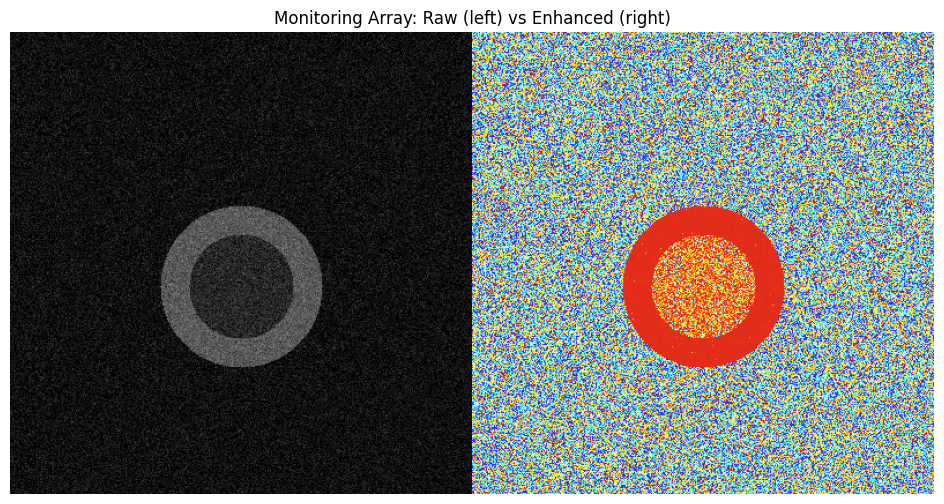

In [5]:
import glob
import matplotlib.pyplot as plt

stills = sorted(glob.glob('output/frame_*.png'))
if stills:
    sample = cv2.imread(stills[len(stills)//2])
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
    plt.title('Monitoring Array: Raw (left) vs Enhanced (right)')
    plt.axis('off')
    plt.show()
else:
    print('No stills saved - check that the video loaded correctly.')


## Running this locally with a live GUI window

```bash
python realtime_echo.py   # or run this notebook with SHOW_WINDOW = True
```

Set `SHOW_WINDOW = True` in the second cell before running on a machine with
a display attached. The loop will pop up a live window titled
*"Raw (left) vs Enhanced (right)"* and update it frame by frame; press `q`
to stop early.
